In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Load Dataset
data = pd.read_csv("IMDB Dataset.csv")

print(data.head())
print(data.shape)

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
(50000, 2)


In [ ]:
# Preprocessing

# Convert text to lowercase
data['review'] = data['review'].str.lower()

# Remove HTML tags
data['review'] = data['review'].apply(lambda x: re.sub(r'<.*?>', '', x))

# Remove special characters
data['review'] = data['review'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

# Remove extra spaces
data['review'] = data['review'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

# Encode labels (positive=1, negative=0)
encoder = LabelEncoder()
data['sentiment'] = encoder.fit_transform(data['sentiment'])

In [ ]:
# Train-Test Split
X = data['review']
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Tokenization & Padding
vocab_size = 10000
max_len = 200

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [ ]:
# Build Bidirectional RNN Model
model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))

# Bidirectional LSTM
model.add(Bidirectional(LSTM(64)))

# Fully Connected Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Compile Model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model.build(input_shape=(None, max_len))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,137 (5.29 MB)

 Trainable params: 1,387,137 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train Model
early_stop = EarlyStopping(monitor='val_loss', patience=2)

history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 422ms/step - accuracy: 0.7715 - loss: 0.4630 - val_accuracy: 0.8691 - val_loss: 0.3304
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 107s 427ms/step - accuracy: 0.8949 - loss: 0.2658 - val_accuracy: 0.8702 - val_loss: 0.3039
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 103s 411ms/step - accuracy: 0.9231 - loss: 0.2029 - val_accuracy: 0.8680 - val_loss: 0.3142
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 139s 401ms/step - accuracy: 0.9456 - loss: 0.1505 - val_accuracy: 0.8719 - val_loss: 0.3938


313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8773 - loss: 0.3636
Test Accuracy: 0.8773000240325928


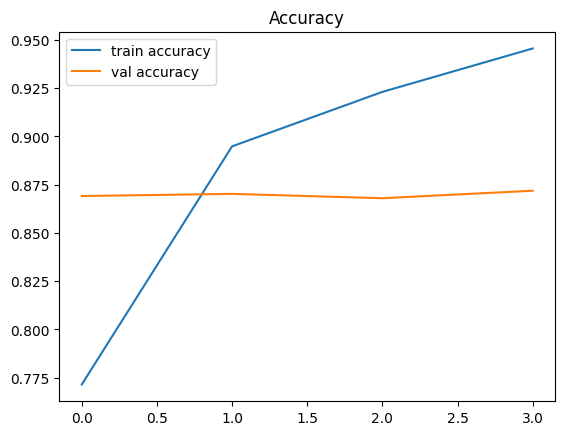

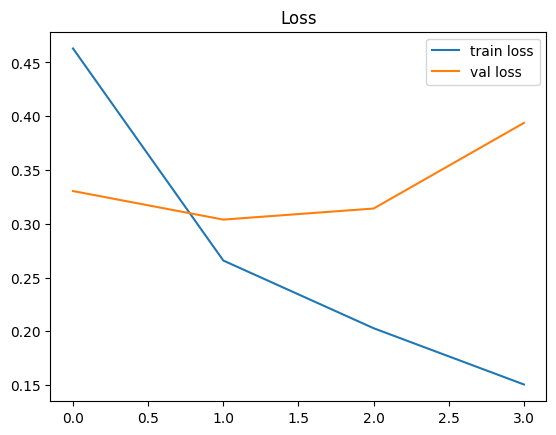

In [ ]:
#Evaluate Model
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", accuracy)

# Plot Accuracy & Loss
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,161,413 (15.87 MB)

 Trainable params: 1,387,137 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,774,276 (10.58 MB)

In [ ]:
# Show Predictions (10 Random Samples)
import random
# Get 10 random indices
indices = random.sample(range(len(X_test)), 10)

for i in indices:
    review = X_test.iloc[i]
    actual = y_test.iloc[i]

    review_clean = review.lower()
    review_clean = re.sub(r'<.*?>', '', review_clean)
    review_clean = re.sub(r'[^a-zA-Z\s]', '', review_clean)
    review_clean = re.sub(r'\s+', ' ', review_clean).strip()

    seq = tokenizer.texts_to_sequences([review_clean])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    pred_prob = model.predict(padded, verbose=0)[0][0]
    pred_label = 1 if pred_prob > 0.5 else 0

    actual_label = "Positive" if actual == 1 else "Negative"
    predicted_label = "Positive" if pred_label == 1 else "Negative"

    print("Review:", review[:200], "...")
    print("Actual:", actual_label)
    print("Predicted:", predicted_label)


Review: warning this may contain spoilersfirst of all i watch a lot lifetime movies and realize they are just thatlifetime movies some are great really some are good and some are bad unfortunately this movie  ...
Actual: Negative
Predicted: Negative
Review: this movie is so good i first seen it when i was six then i bought it recently and i still love it im now plus the acting was great and madonna is my idol and she did a phat job alot of people didnt l ...
Actual: Positive
Predicted: Positive
Review: i have watched this episode more often than any other tftc episode it is that enjoyable and it is quite scary but all in good ghoulish fun a woman kills her nd husband but runs into a problem when an  ...
Actual: Positive
Predicted: Positive
Review: after seeing the tv commercials for this film i marched to my local cinema expecting a lot of laughs in the end it was one of the longest mins i have ever spent the wog boy really did fail to provide  ...
Actual: Negative
Predicted: Negative
